Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

Epoch 0: Train MSE 0.019349, Val MAE 0.070778
Epoch 1: Train MSE 0.009152, Val MAE 0.061491
Epoch 2: Train MSE 0.006891, Val MAE 0.055126
Epoch 3: Train MSE 0.005684, Val MAE 0.048694
Epoch 4: Train MSE 0.004977, Val MAE 0.045280
Epoch 5: Train MSE 0.004331, Val MAE 0.042501
Epoch 6: Train MSE 0.003863, Val MAE 0.039991
Epoch 7: Train MSE 0.003544, Val MAE 0.038823
Epoch 8: Train MSE 0.003285, Val MAE 0.036877
Epoch 9: Train MSE 0.002983, Val MAE 0.038133
Epoch 10: Train MSE 0.002732, Val MAE 0.033541
Epoch 11: Train MSE 0.002507, Val MAE 0.032268
Epoch 12: Train MSE 0.002249, Val MAE 0.030518
Epoch 13: Train MSE 0.002125, Val MAE 0.029209
Epoch 14: Train MSE 0.001929, Val MAE 0.028900
Epoch 15: Train MSE 0.001766, Val MAE 0.026345
Epoch 16: Train MSE 0.001636, Val MAE 0.025754
Epoch 17: Train MSE 0.001457, Val MAE 0.026164
Epoch 18: Train MSE 0.001371, Val MAE 0.023497
Epoch 19: Train MSE 0.001271, Val MAE 0.022330
Epoch 20: Train MSE 0.001180, Val MAE 0.021258
Epoch 21: Train MSE 0.0

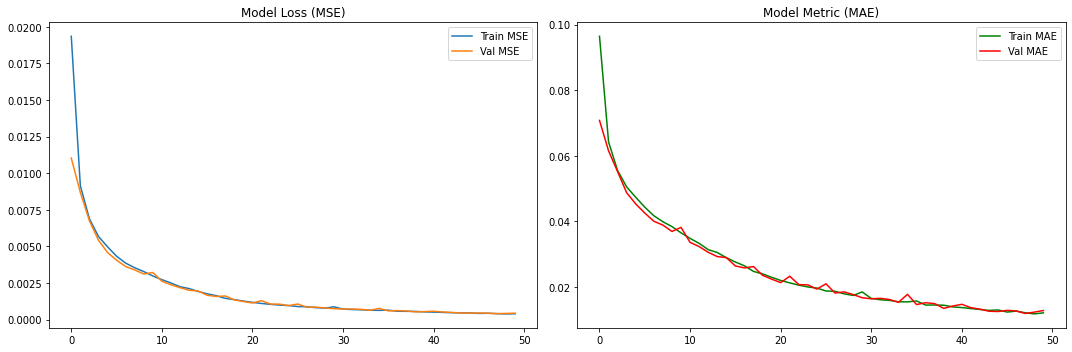

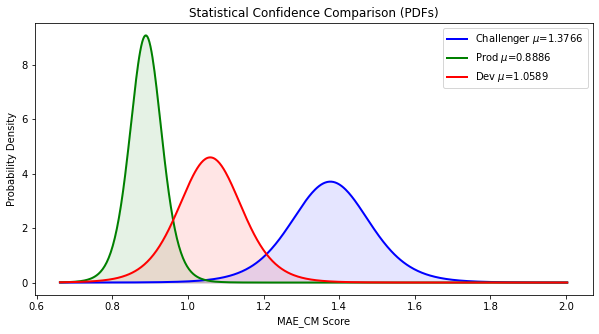

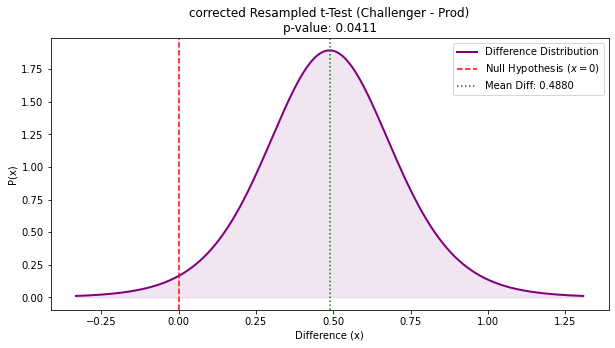

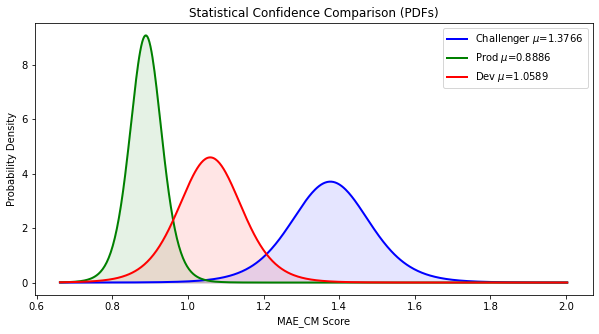

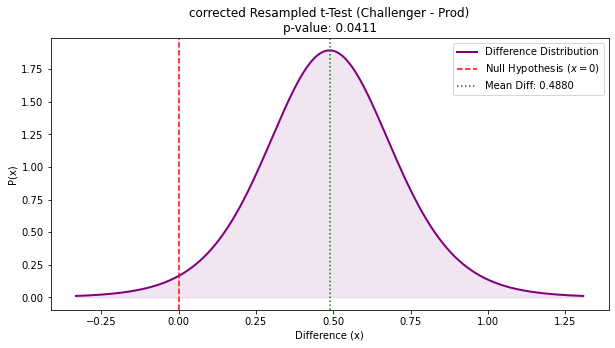

⚠️ Difference not significant or model is worse (p=0.0411)

--- Comparing Registry Aliases ---


New Best! 1.3766175508499146 > 1.0589282870292664. Updating models on DagsHub


2026/04/14 22:05:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 22:05:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Project_Model_Z_Predictor_V1' already exists. Creating a new version of this model...
2026/04/14 22:06:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Project_Model_Z_Predictor_V1, version 6
Created version '6' of model 'Project_Model_Z_Predictor_V1'.
/var/folders/9w/6516vw7x2gbc3llv8dbzm6vw0000gn/T/ipykernel_20980/4194897478.py:318: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: http

🚀 New model beat @dev! Registered and aliased.
🏃 View run Z-Depth-Training-LSTM at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/001d93271eca4a838b737e67b1c27065
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0


In [ ]:
import sys
sys.path.append("../../scripts")

import dagshub
import mlflow
import ml_utils as mlutils

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# --- 1. SETUP DAGSHUB & CONFIG ---
dagshub.init(repo_owner="SamuelFredricBerg", repo_name="4dt907", mlflow=True)
# New Name for the Z-Predictor Project
project_name = "Project_Model_Z_Predictor_V1"
utils = mlutils.mlutils(project_name)

import random


config = {
    "variant": "LSTM-Z-Lifting",
    "seq_length": 60,
    "batch_size": 32,
    "hidden_size": 128,
    "num_layers": 2,
    "learning_rate": 0.001,
    "rnn_type": 'LSTM',


    "epochs": 50,
    "patience": 5,
    "seed": 42
}
SEED = config["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 2. DATASET & MODEL CLASSES ---
class KinectFolderDataset(Dataset):
    def __init__(self, folder_path, seq_length=30):
        self.X_seqs = []
        self.y_seqs = []
        self.seq_length = seq_length
        file_paths = glob.glob(os.path.join(folder_path, "*.csv"))
        
        for path in file_paths:
            df = pd.read_csv(path)
            all_cols = [c for c in df.columns if c != 'FrameNo']
            x_y_cols = sorted([c for c in all_cols if c.endswith('_x') or c.endswith('_y')])
            z_cols = sorted([c for c in all_cols if c.endswith('_z')])
            
            x_data = df[x_y_cols].values.astype(np.float32)
            y_data = df[z_cols].values.astype(np.float32)
            
            if len(df) >= seq_length:
                for i in range(len(df) - seq_length + 1):
                    self.X_seqs.append(x_data[i : i + seq_length])
                    self.y_seqs.append(y_data[i : i + seq_length])
            
    def __len__(self): return len(self.X_seqs)
    def __getitem__(self, idx):
        return torch.tensor(self.X_seqs[idx]), torch.tensor(self.y_seqs[idx])

class PoseLiftingModel(nn.Module):
    def __init__(self, input_size=26, hidden_size=128, num_layers=2, output_size=13, rnn_type='LSTM'):
        super(PoseLiftingModel, self).__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.relu(out)
        return self.fc(out)

# --- 3. DATA PREP ---
folder = "../../data/kinect_good_preprocessed_A9_mediapipe " # Ensure space in path is handled
full_dataset = KinectFolderDataset(folder, seq_length=config["seq_length"])

indices = list(range(len(full_dataset)))
np.random.shuffle(indices)
test_indices = indices[:10]
train_val_indices = indices[10:]

train_val_subset = Subset(full_dataset, train_val_indices)
test_subset = Subset(full_dataset, test_indices)

train_size = int(0.8 * len(train_val_subset))
val_size = len(train_val_subset) - train_size
train_data, val_data = random_split(train_val_subset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
val_loader = DataLoader(val_data, batch_size=config["batch_size"], shuffle=False)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

# --- 4. MAIN TRAINING WITH MLFLOW ---
with mlflow.start_run(run_name="Z-Depth-Training-LSTM") as run:
    mlflow.log_params(config)
    
    model = PoseLiftingModel(
        input_size=26, 
        hidden_size=config["hidden_size"], 
        num_layers=config["num_layers"], 
        output_size=13, 
        rnn_type=config["rnn_type"]
    )
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    history = {
        'train_mse': [], 
        'val_mse': [], 
        'train_mae': [], 
        'val_mae': []
    }
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(config["epochs"]):
        model.train()
        train_running_loss = 0.0
        train_running_mae = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()
            train_running_mae += torch.mean(torch.abs(outputs - targets)).item()
        
        model.eval()
        val_running_loss = 0.0
        val_running_mae = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                v_loss = criterion(outputs, targets)
                val_running_loss += v_loss.item()
                val_running_mae += torch.mean(torch.abs(outputs - targets)).item()
                
        # Calculate Averages
        metrics = {
            "Train_MSE": train_running_loss / len(train_loader),
            "Val_MSE": val_running_loss / len(val_loader),
            "Train_MAE": train_running_mae / len(train_loader),
            "Val_MAE": val_running_mae / len(val_loader)
        }
        
        metrics = {
            "Train_MSE": train_running_loss / len(train_loader),
            "Val_MSE": val_running_loss / len(val_loader),
            "Train_MAE": train_running_mae / len(train_loader),
            "Val_MAE": val_running_mae / len(val_loader)
        }

        # This loop now correctly finds 'train_mse', 'val_mse', etc.
        for k, v in metrics.items():
            history[k.lower()].append(v)
            
        mlflow.log_metrics(metrics, step=epoch)

        print(f"Epoch {epoch}: Train MSE {metrics['Train_MSE']:.6f}, Val MAE {metrics['Val_MAE']:.6f}")

        # Early Stopping Logic
        if metrics["Val_MSE"] < best_val_loss:
            best_val_loss = metrics["Val_MSE"]
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1
            if counter >= config["patience"]:
                print("Early stopping triggered.")
                break

    # --- 5. PLOTS & ARTIFACTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history['train_mse'], label='Train MSE'); ax1.plot(history['val_mse'], label='Val MSE')
    ax1.set_title('Model Loss (MSE)'); ax1.legend()
    
    ax2.plot(history['train_mae'], label='Train MAE', color='green'); ax2.plot(history['val_mae'], label='Val MAE', color='red')
    ax2.set_title('Model Metric (MAE)'); ax2.legend()
    
    plt.tight_layout()
    plt.savefig("z_learning_plots.png")
    mlflow.log_artifact("z_learning_plots.png")

    # Final Summary Table (CSV)
    summary_df = pd.DataFrame(history)
    summary_df.to_csv("training_history.csv", index=False)
    mlflow.log_artifact("training_history.csv")

    # --- 5. PER-JOINT EVALUATION (Add this to your main script) ---
    print("\n--- Running Final Evaluation on 10 Random Sequences ---")
    
    # Names of the 13 joints
    joint_names = [
        "nose", "left_shoulder", "left_elbow", "right_shoulder", "right_elbow",
        "left_wrist", "right_wrist", "left_hip", "right_hip", "left_knee", 
        "right_knee", "left_ankle", "right_ankle"
    ]

    all_seq_errors = []
    # Dictionary to track errors per joint across all test samples
    joint_error_accumulator = {name: [] for name in joint_names}

    model.eval() # Ensure model is in eval mode
    with torch.no_grad():
        for inputs, targets in test_loader:
            # Move to device if you're using GPU
            predictions = model(inputs)
            
            # 1. Sequence-wide Mean Error
            dist_cm = torch.abs(predictions - targets) * 100
            all_seq_errors.append(torch.mean(dist_cm).item())
            
            # 2. Per-Joint Error (Mean across Batch and Sequence dims)
            # dist_cm shape is [Batch, Seq, Joints]
            error_per_joint = torch.mean(dist_cm, dim=(0, 1)).cpu().numpy()
            
            for i, name in enumerate(joint_names):
                joint_error_accumulator[name].append(error_per_joint[i])

    # Calculate Aggregates
    grand_average = np.mean(all_seq_errors)
    std_dev = np.std(all_seq_errors)
    
    # Calculate Mean error per joint
    mean_joint_errors = {name: np.mean(joint_error_accumulator[name]) for name in joint_names}

    # --- 6. LOG TO DAGSHUB ---
    # Log the summary stats
    mlflow.log_metrics({
        "Grand_Avg_Test_MAE_cm": grand_average,
        "Test_MAE_StdDev": std_dev
    })
    
    # Log individual joint errors (extremely useful for DagsHub table comparison)
    mlflow.log_metrics({f"Joint_Err_{k}": v for k, v in mean_joint_errors.items()})

    # Save a CSV artifact for the full report
    report_df = pd.DataFrame.from_dict(mean_joint_errors, orient='index', columns=['Mean_Error_cm'])
    report_df.to_csv("per_joint_evaluation.csv")
    mlflow.log_artifact("per_joint_evaluation.csv")

    print(f"Evaluation Complete. Grand Avg Error: {grand_average:.3f} cm")

    # --- 7. PREPARE SCORES FOR STATISTICAL COMPARISON ---
    # Convert your list of 10 sequence errors into a DataFrame
    current_scores_df = pd.DataFrame({
        'mae_cm': all_seq_errors  # This matches the 'metric' name we will pass
    })
    
    # Save this to CSV so the 'compare' methods can download it later
    current_scores_df.to_csv("cv_fold_scores.csv", index=False)
    mlflow.log_artifact("cv_fold_scores.csv")

    # --- 8. STATISTICAL RADIOGRAPH (T-Test) ---
    # We pass metric="mae_cm" to match the column name above
    is_better, p_val = utils.is_challenger_statistically_better(
        current_scores_df, 
        metric="mae_cm"
    )

    # --- 8. STATISTICAL RADIOGRAPH (T-Test) ---
    is_better, p_val = utils.is_challenger_statistically_better(
        current_scores_df, 
        metric="mae_cm"
    )

    # SAFE LOGGING: Only log if files exist (they won't on the very first run)
    import os
    if os.path.exists("model_confidence_comparison.png"):
        mlflow.log_artifact("model_confidence_comparison.png")
    
    if os.path.exists("challenger_vs_prod_ttest.png"):
        mlflow.log_artifact("challenger_vs_prod_ttest.png")

    if is_better:
        print(f"🚀 Challenger is statistically superior (p={p_val:.4f})")
    else:
        print(f"⚠️ Difference not significant or model is worse (p={p_val:.4f})")

    # --- 9. REGISTRY VALIDATION ---
    # This uses your new function to pull @prod and @dev and test them 
    # against the CURRENT test_loader
    print("\n--- Comparing Registry Aliases ---")
    registry_results = utils.compare_pytorch_aliases(test_loader, joint_names)
    
    # Optional: Log the average of these registry results to MLflow
    for alias, scores in registry_results.items():
        if scores is not None:
            mlflow.log_metric(f"Registry_{alias}_Mean_MAE", np.mean(scores))

    # --- 6. CHALLENGER CHECK ---
    # We use Val_MAE as the deciding metric for depth accuracy
    if utils.auto_check_challenger(run.info.run_id, metric_name="Grand_Avg_Test_MAE_cm"):
        # Log the PyTorch model
        mlflow.pytorch.log_model(model, "model", registered_model_name=project_name)
        
        # Set dev alias
        latest_v = utils.client.get_latest_versions(project_name)[0].version
        utils.client.set_registered_model_alias(project_name, "dev", latest_v)
        print("🚀 New model beat @dev! Registered and aliased.")
    else:
        print("❌ Did not beat current @dev.")